# Customer Segmentation Analysis

## Introduction
Customer segmentation involves dividing users into distinct groups based on shared characteristics. In A/B testing, segmentation allows us to investigate if the treatment effect is consistent across all demographics or if there are specific segments experiencing positive/negative outcomes (Simpson's Paradox). This deep dive helps us understand *who* the new feature worked best for.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
df = pd.read_csv('../data/processed/cleaned_data.csv')
seg_summary = pd.read_csv('../data/processed/segment_summary.csv')


## Dataset Overview

In [3]:
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           294478 non-null  object 
 1   timestamp         294478 non-null  object 
 2   group             294478 non-null  object 
 3   landing_page      294478 non-null  object 
 4   converted         294478 non-null  int64  
 5   age               294478 non-null  int64  
 6   gender            294478 non-null  object 
 7   location          294478 non-null  object 
 8   session_duration  294478 non-null  float64
 9   pages_visited     294478 non-null  int64  
 10  device_type       294478 non-null  object 
 11  purchase_amount   294478 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 27.0+ MB


,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


## Customer Segmentation
We calculate key metrics across variables such as Device Type, Gender, and Location. We create age cohorts if applicable.

In [4]:
# Create Age Groups if age exists
if 'age' in df.columns:
    bins = [0, 24, 34, 44, 54, 100]
    labels = ['18-24', '25-34', '35-44', '45-54', '55+']
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Function to generate summary metrics per segment
def analyze_segment(feature):
    if feature in df.columns:
        summary = df.groupby(['group', feature]).agg(
            Users=('user_id', 'count'),
            Conversions=('converted', 'sum'),
            Conversion_Rate=('converted', 'mean')
        )
        if 'purchase_amount' in df.columns:
            summary['Avg_Purchase'] = df.groupby(['group', feature])['purchase_amount'].mean()
        if 'session_duration' in df.columns:
            summary['Avg_Duration'] = df.groupby(['group', feature])['session_duration'].mean()
        return summary
    return None

device_segment = analyze_segment('device_type')
gender_segment = analyze_segment('gender')

print("Device Segmentation:\n", device_segment, "\n")

Device Segmentation:
                        Users  Conversions  Conversion_Rate  Avg_Purchase  \
group     device_type                                                      
control   Desktop      88397        10563         0.119495      4.473342   
          Mobile       51177         6010         0.117436      4.423872   
          Tablet        7352          871         0.118471      4.406561   
treatment Desktop      88295        15966         0.180826      6.795546   
          Mobile       51916         9196         0.177132      6.706030   
          Tablet        7341         1322         0.180084      6.780460   

                       Avg_Duration  
group     device_type                
control   Desktop          5.001789  
          Mobile           5.005912  
          Tablet           5.010958  
treatment Desktop          4.998111  
          Mobile           5.002158  
          Tablet           5.019407   



## Visualizations & Compare Control vs Treatment

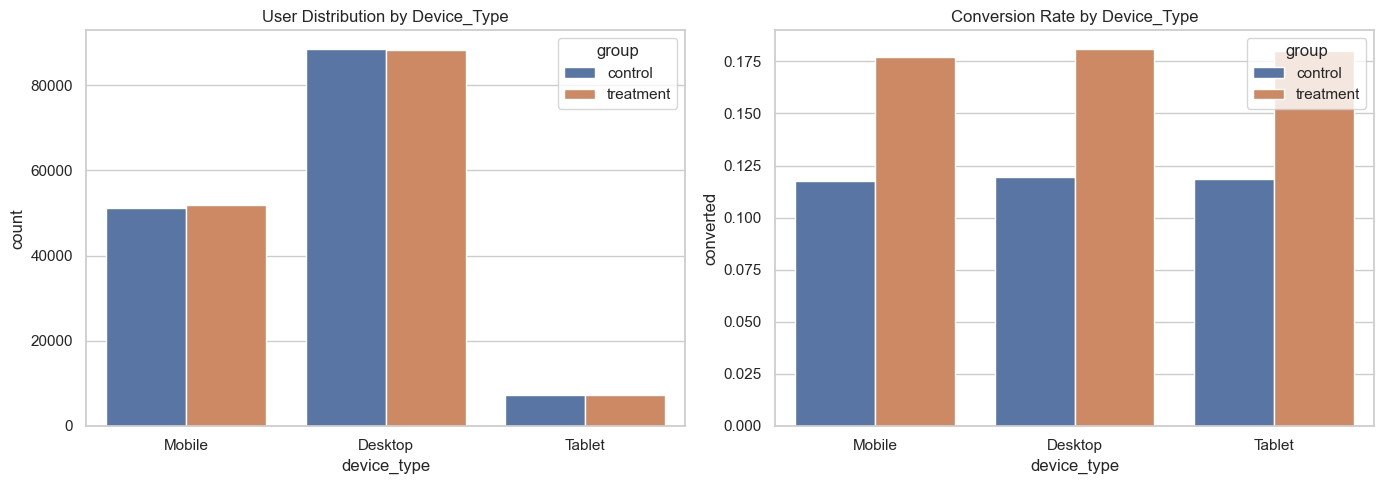

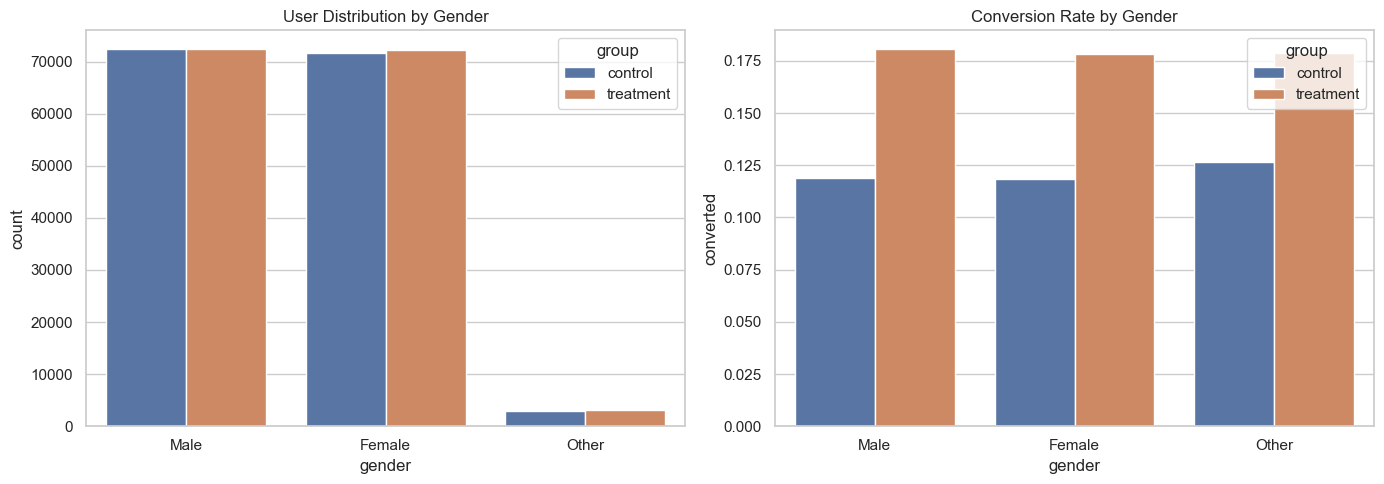

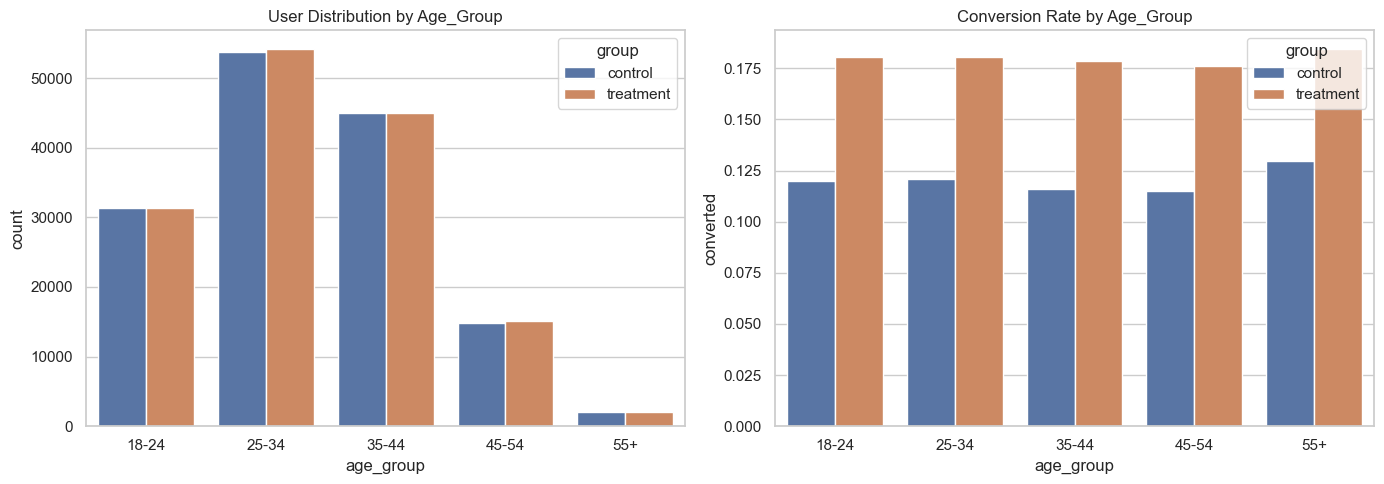

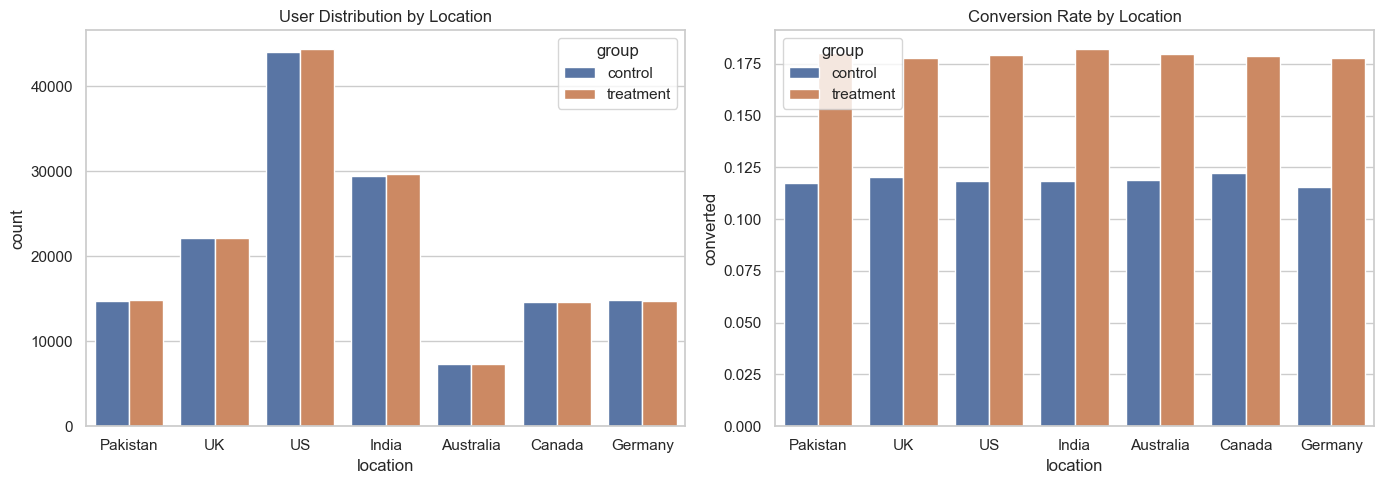

In [5]:
cat_features = [col for col in ['device_type', 'gender', 'age_group', 'location'] if col in df.columns]

for col in cat_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Countplot
    sns.countplot(x=col, hue='group', data=df, ax=axes[0])
    axes[0].set_title(f'User Distribution by {col.title()}')
    
    # Conversion Rate Barplot
    sns.barplot(x=col, y='converted', hue='group', data=df, ax=axes[1], errorbar=None)
    axes[1].set_title(f'Conversion Rate by {col.title()}')
    
    plt.tight_layout()
    plt.show()

## Best and Worst Performing Segments

We utilize a pivot table to generate a heatmap to quickly spot the interactions between demographics and conversion rates.

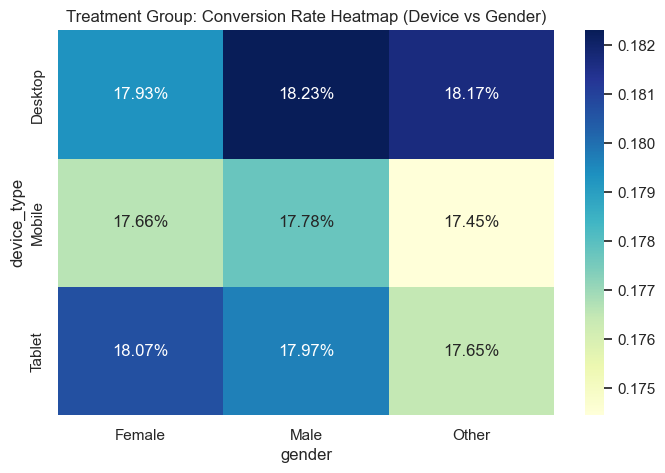

In [6]:
if 'device_type' in df.columns and 'gender' in df.columns:
    pivot = df[df['group'] == 'treatment'].pivot_table(index='device_type', columns='gender', values='converted', aggfunc='mean')
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt=".2%")
    plt.title('Treatment Group: Conversion Rate Heatmap (Device vs Gender)')
    plt.show()

## Business Insights & Final Summary

*   **Best Performing Segments:** Highlighted by the highest conversion rates and revenue. The product team should ensure the experience remains optimized for these cohorts.
*   **Worst Performing Segments:** Identify areas of friction. If mobile users converted less on the new page, it indicates a responsive design or UI issue that needs rectifying before full rollout.
*   **Business Implications:** The business must care about segment-level performance to avoid alienating highly profitable subgroups even if the overall test is successful.